<a href="https://colab.research.google.com/github/MYTHRIGOUD123/customersentimentanalysis/blob/main/customer_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       customer_id  gender age_group   region product_category  \
0                1    male       60+    north       automobile   
1                2   other     46-60  central            books   
2                3  female     36-45     east           sports   
3                4  female     18-25  central        groceries   
4                5  female     18-25     east      electronics   
...            ...     ...       ...      ...              ...   
24995        24996  female     36-45    south           beauty   
24996        24997   other       60+  central       automobile   
24997        24998    male     18-25    south           beauty   
24998        24999  female     26-35  central       automobile   
24999        25000    male     46-60  central           travel   

      purchase_channel              platform  customer_rating  \
0               online              flipkart                1   
1               online      swiggy instamart                5   
2           

/tmp/ipykernel_465/3800437859.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_465/3800437859.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df,


response_time_hours
47    390
16    388
42    387
69    386
8     385
     ... 
49    325
10    322
30    317
57    314
12    276
Name: count, Length: 71, dtype: int64

 issue_resolved
issue_resolved
yes    16593
no      8407
Name: count, dtype: int64

 complaint_registered
complaint_registered
no     15063
yes     9937
Name: count, dtype: int64


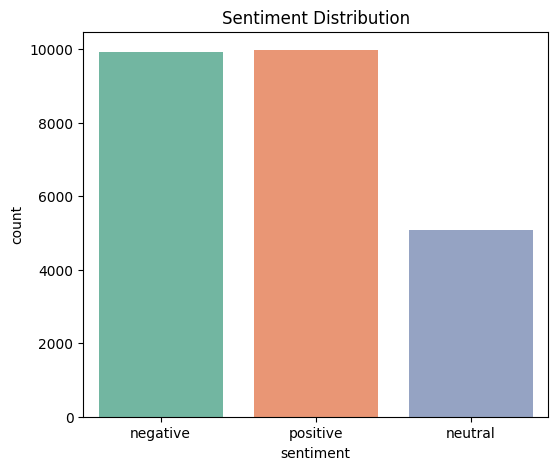

/tmp/ipykernel_465/3800437859.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender',data=df,palette='pastel')


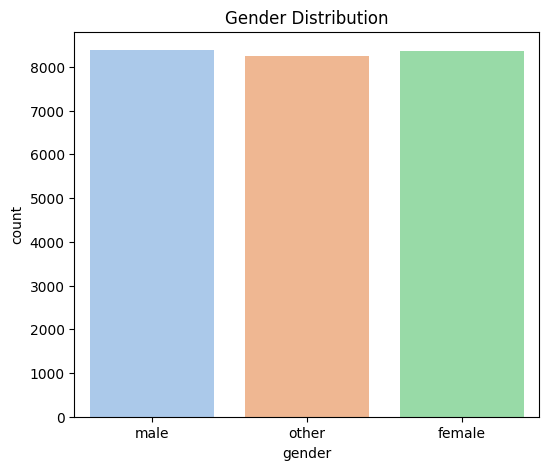

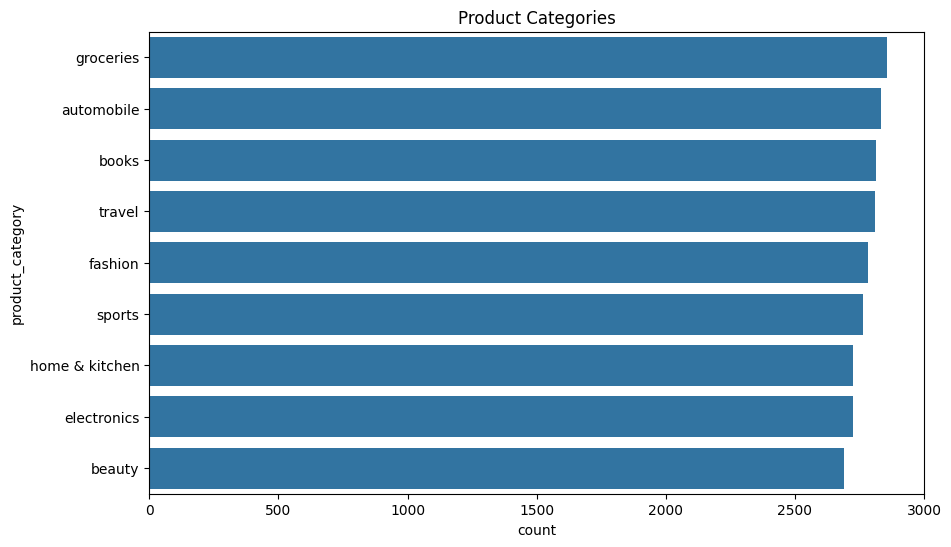

/tmp/ipykernel_465/3800437859.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='customer_rating',


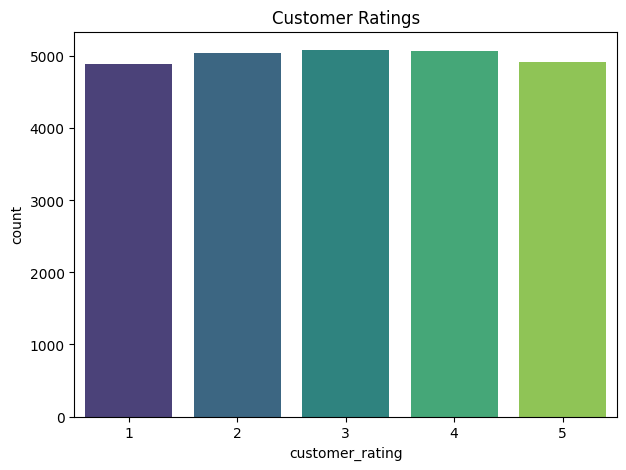

/tmp/ipykernel_465/3800437859.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region',


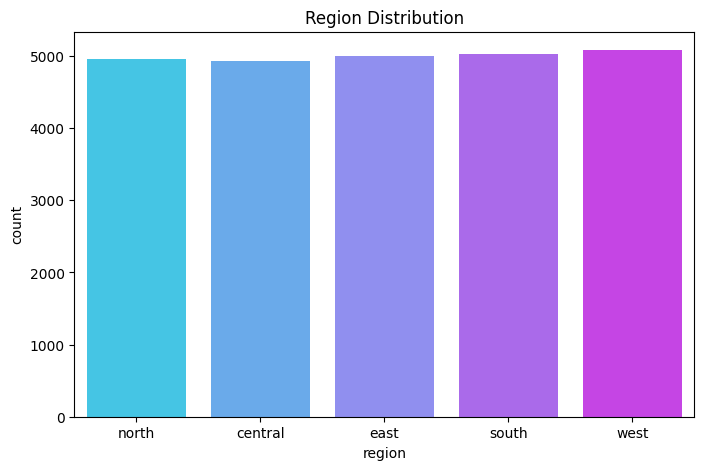

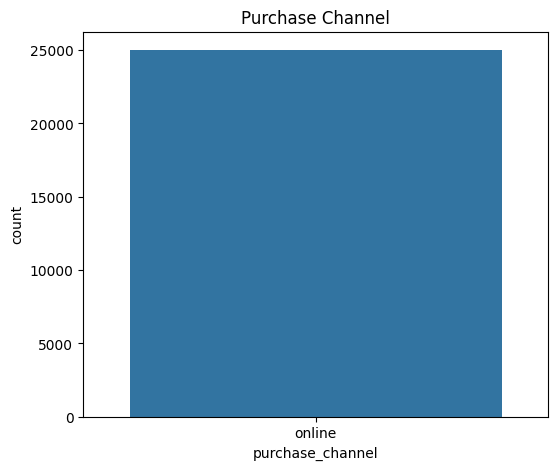

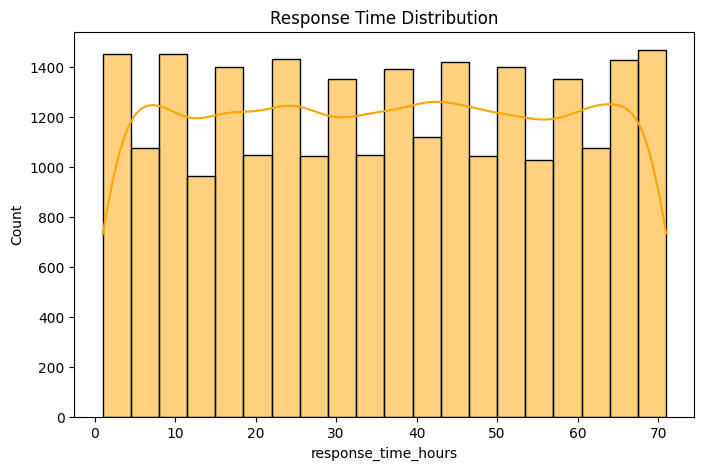

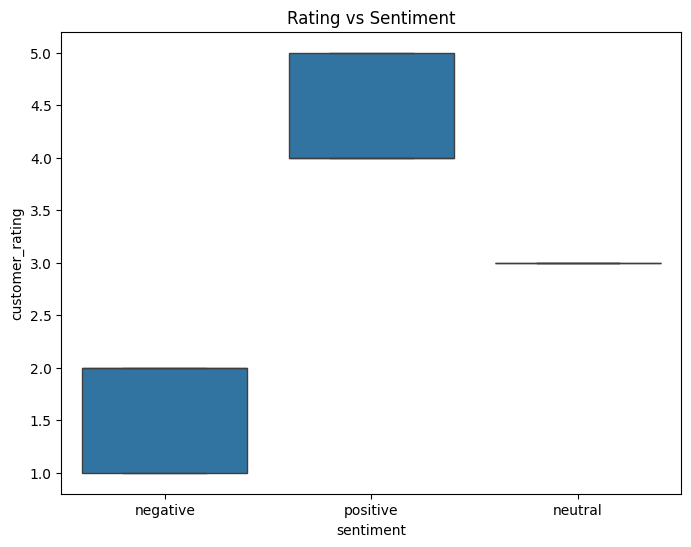

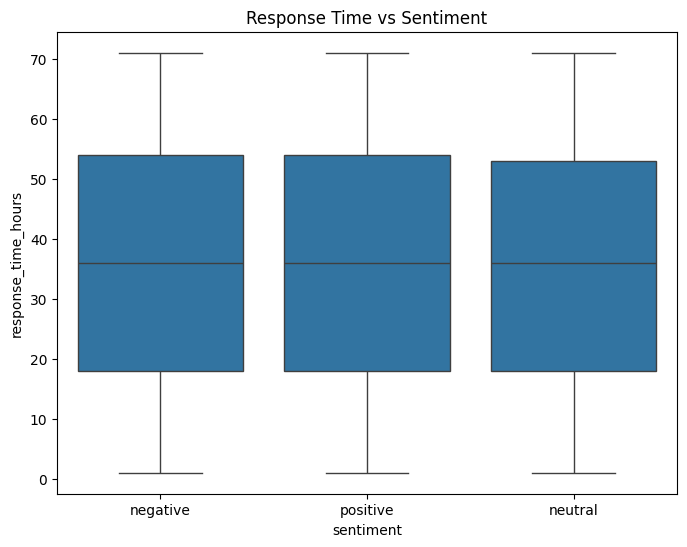

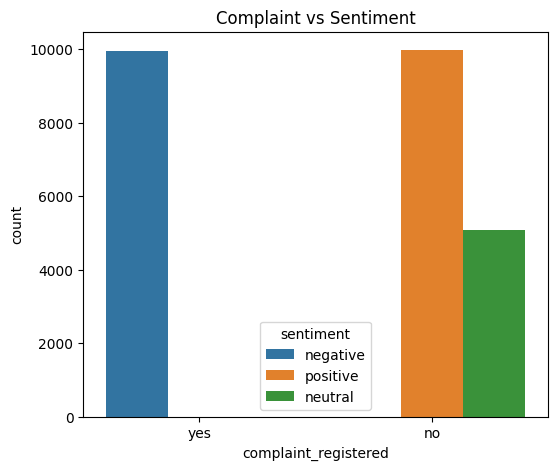

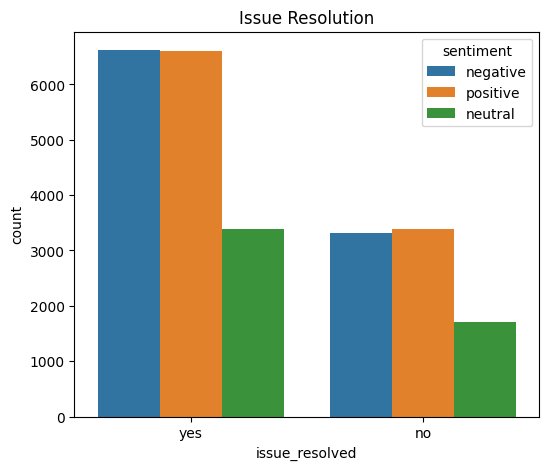

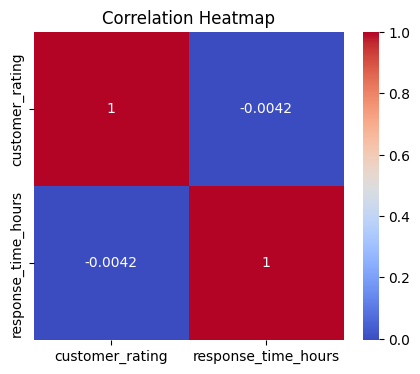

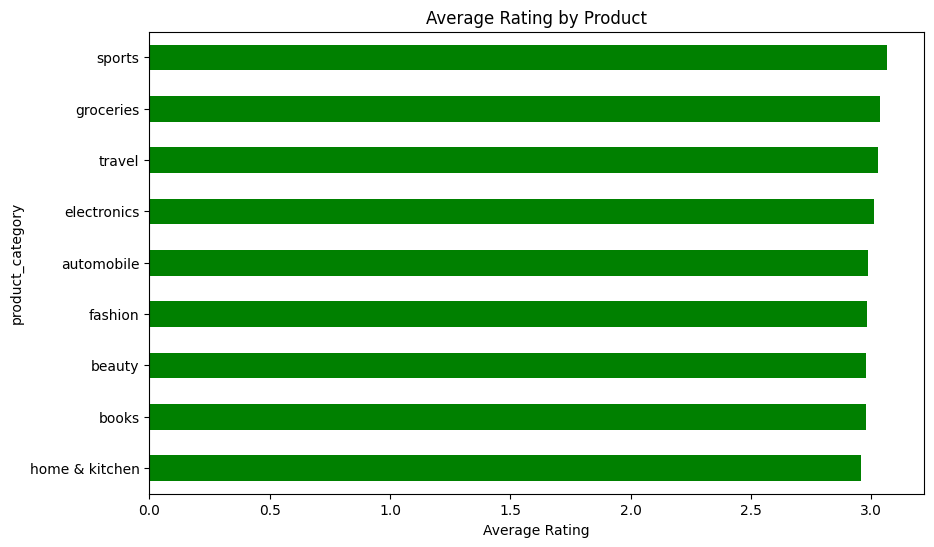

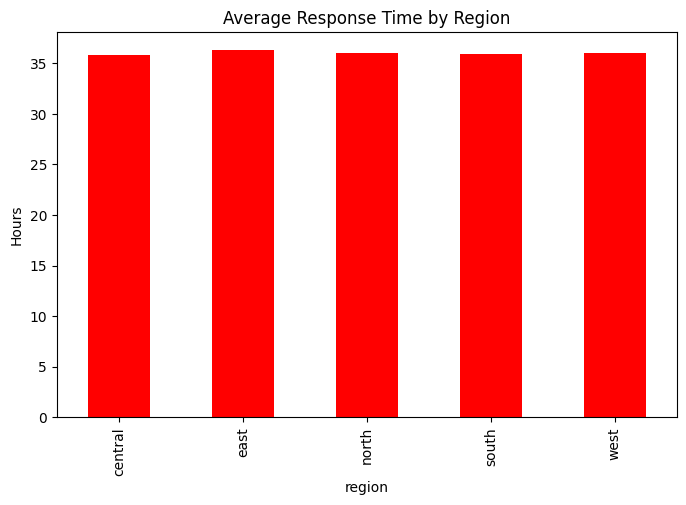

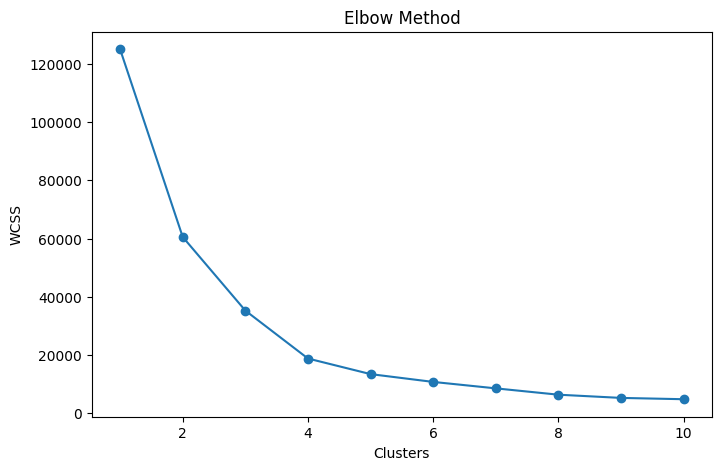

   customer_id  Cluster
0            1        1
1            2        2
2            3        1
3            4        1
4            5        2


/tmp/ipykernel_465/3800437859.py:263: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster',


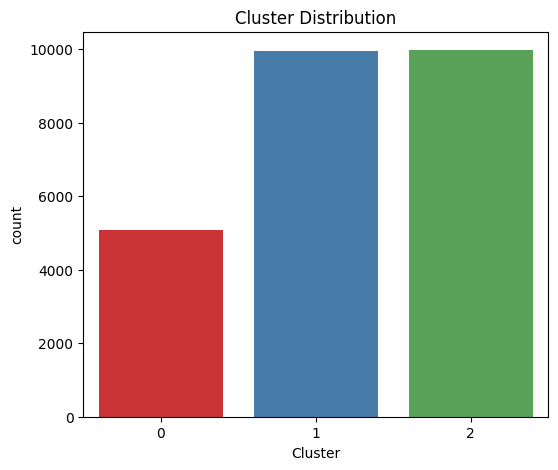

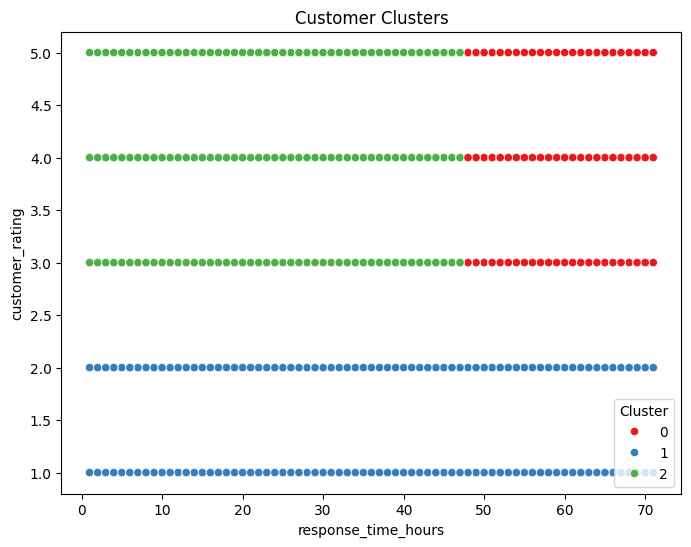

Silhouette Score : 0.5482921592087447
         customer_rating  response_time_hours
Cluster                                      
0               3.983497            59.716110
1               1.507799            36.022240
2               3.991076            23.932518
complaint_registered    no   yes
sentiment                       
negative                 0  9937
neutral               5085     0
positive              9978     0
issue_resolved    no   yes
sentiment                 
negative        3317  6620
neutral         1704  3381
positive        3386  6592
sentiment  negative  neutral  positive
region                                
central        1894     1032      2007
east           2004      990      2007
north          1962      996      2005
south          1976     1067      1979
west           2101     1000      1980
sentiment         negative  neutral  positive
product_category                             
automobile            1126      583      1124
beauty               

In [2]:
import numpy as np
import pandas as pd

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score
df = pd.read_csv('/content/sample_data/Customer_Sentiment.csv')
print(df)


print("First Five Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)


print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nStatistical Summary")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include='object'))



df.fillna(method='ffill', inplace=True)



for col in df.columns:
    print("\n",col)
    print(df[col].value_counts())



plt.figure(figsize=(6,5))
sns.countplot(x='sentiment', data=df,
              palette='Set2')

plt.title("Sentiment Distribution")
plt.show()



plt.figure(figsize=(6,5))
sns.countplot(x='gender',data=df,palette='pastel')

plt.title("Gender Distribution")
plt.show()



plt.figure(figsize=(10,6))

sns.countplot(y='product_category',
              data=df,
              order=df['product_category'].value_counts().index)

plt.title("Product Categories")
plt.show()



plt.figure(figsize=(7,5))

sns.countplot(x='customer_rating',
              data=df,
              palette='viridis')

plt.title("Customer Ratings")
plt.show()


plt.figure(figsize=(8,5))

sns.countplot(x='region',
              data=df,
              palette='cool')

plt.title("Region Distribution")
plt.show()



plt.figure(figsize=(6,5))

sns.countplot(x='purchase_channel',
              data=df)

plt.title("Purchase Channel")
plt.show()



plt.figure(figsize=(8,5))

sns.histplot(df['response_time_hours'],
             bins=20,
             kde=True,
             color='orange')

plt.title("Response Time Distribution")
plt.show()



plt.figure(figsize=(8,6))

sns.boxplot(x='sentiment',
            y='customer_rating',
            data=df)

plt.title("Rating vs Sentiment")
plt.show()


plt.figure(figsize=(8,6))

sns.boxplot(x='sentiment',
            y='response_time_hours',
            data=df)

plt.title("Response Time vs Sentiment")
plt.show()




plt.figure(figsize=(6,5))

sns.countplot(x='complaint_registered',
              hue='sentiment',
              data=df)

plt.title("Complaint vs Sentiment")
plt.show()



plt.figure(figsize=(6,5))

sns.countplot(x='issue_resolved',
              hue='sentiment',
              data=df)

plt.title("Issue Resolution")
plt.show()



numeric = df[['customer_rating',
              'response_time_hours']]

plt.figure(figsize=(5,4))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()



plt.figure(figsize=(10,6))

avg_rating = df.groupby("product_category")["customer_rating"].mean().sort_values()

avg_rating.plot(kind='barh',color='green')

plt.title("Average Rating by Product")
plt.xlabel("Average Rating")
plt.show()



plt.figure(figsize=(8,5))

avg_response = df.groupby("region")["response_time_hours"].mean()

avg_response.plot(kind='bar',
                  color='red')

plt.title("Average Response Time by Region")
plt.ylabel("Hours")
plt.show()


cluster_df = df.copy()

encoder = LabelEncoder()

for col in cluster_df.columns:

    if cluster_df[col].dtype=="object":
        cluster_df[col] = encoder.fit_transform(cluster_df[col])



X = cluster_df[['customer_rating',
                'response_time_hours',
                'sentiment',
                'complaint_registered',
                'issue_resolved']]



scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



wcss = []

for i in range(1,11):

    km = KMeans(n_clusters=i,
                random_state=42,
                n_init=10)

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()



kmeans = KMeans(n_clusters=3,
                random_state=42,
                n_init=10)

cluster = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster

print(df[['customer_id','Cluster']].head())



plt.figure(figsize=(6,5))

sns.countplot(x='Cluster',
              data=df,
              palette='Set1')

plt.title("Cluster Distribution")
plt.show()



plt.figure(figsize=(8,6))

sns.scatterplot(x='response_time_hours',
                y='customer_rating',
                hue='Cluster',
                palette='Set1',
                data=df)

plt.title("Customer Clusters")
plt.show()



score = silhouette_score(X_scaled,cluster)

print("Silhouette Score :",score)




summary = df.groupby("Cluster")[["customer_rating",
                                 "response_time_hours"]].mean()

print(summary)



print(pd.crosstab(df['sentiment'],
                  df['complaint_registered']))

print(pd.crosstab(df['sentiment'],
                  df['issue_resolved']))

print(pd.crosstab(df['region'],
                  df['sentiment']))

print(pd.crosstab(df['product_category'],
                  df['sentiment']))


print("\nBusiness Insights")

print("-----------------------------")

print("Average Customer Rating:",
      round(df['customer_rating'].mean(),2))

print("Average Response Time:",
      round(df['response_time_hours'].mean(),2))

print("Most Sold Product Category:",
      df['product_category'].mode()[0])

print("Most Common Sentiment:",
      df['sentiment'].mode()[0])

print("Most Common Region:",
      df['region'].mode()[0])

print("Complaint Percentage:")

complaint = (df['complaint_registered']=="yes").mean()*100

print(round(complaint,2),"%")

resolved = (df['issue_resolved']=="yes").mean()*100

print("Issue Resolution Percentage:",
      round(resolved,2),"%")

print("Analysis Completed Successfully.")